# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

# --------------------------------

# 1. 라이브러리 불러오기

In [160]:
# 1. 라이브러리 불러오기
# 기본 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 제거
import warnings
warnings.filterwarnings('ignore')

# 데이터 분리
from sklearn.model_selection import train_test_split

# 전처리
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature Selection / 중요도 확인용
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# 모델 평가
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 클래스 불균형 확인 및 가중치 계산
from sklearn.utils.class_weight import compute_class_weight

# 딥러닝 모델 구축
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 재현성 고정
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# pandas 출력 옵션
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 시각화 기본 설정
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기+기본정보 확인

In [161]:
# 데이터 파일 불러오기
df = pd.read_csv("train2.csv")

# 데이터 크기 확인
print("데이터 크기:", df.shape)

# 상위 3개 행 확인
df.head(3)

데이터 크기: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",3,7,11.27,4,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",3,4,11.27,4,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",3,7,11.27,4,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good


In [162]:
df.info()
# 모든 칼럼이 결측치 x
# 'Name,Occupation', 'Type_of_Loan' , 'Credit_Mix' , 'Payment_of_Min_Amoun't, 'Payment_Behaviour', 'Credit_Score'(정답값) : 범주형
# 나머지는 수치형

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

In [163]:
# 수치형 변수들의 기초통계량 확인
df.describe()
# 전체적인 구조를 살펴봤을 때, 데이터별로 값의 범위가 매우 다르기 때문에 스케일링이 필수적인 것으로 생각됨.

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633330,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [164]:
df['Credit_Score'].value_counts(normalize=True)
# Standard: 53%
# Poor: 28%
# Good: 17%

# 일반적으로 생각하기에도 표준이 가장 높은 것으로 나옴.

,proportion
Credit_Score,
Standard,0.53174
Poor,0.28998
Good,0.17828


# 데이터 전처리

# 3. 불필요한 컬럼 제거

In [165]:
# 제거할 컬럼 목록
drop_cols = [
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

# 실제 데이터에 존재하는 컬럼만 제거
df = df.drop(columns=drop_cols, errors='ignore')

# 제거 후 데이터 크기 확인
print("컬럼 제거 후 데이터 크기:", df.shape)

# 남은 컬럼 확인
df.head(1)

# 'ID','Customer_ID','Name','SSN' 칼럼들은 개인을 식별하기 위한 정보이기 때문에 제거한다.

컬럼 제거 후 데이터 크기: (100000, 24)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23,Scientist,19114.12,1824.843333,3,4,3,4,"auto loan,credit-builder loan,personal loan,ho...",3,7,11.27,4,Good,809.98,26.82262,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good


# 4. 이상치/문자 섞인 수치형 컬럼 정리
### 숫자형처럼 보이지만 이상한 문자나 공백 등이 포함되어 있을 수 있으므로, 이를 제거하기 위한 목적으로 실행한다.

In [166]:
# 수치형으로 다뤄야 하는 컬럼 목록
numeric_cols = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Credit_History_Age',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

In [167]:
# 숫자형 컬럼에 섞인 문자, 공백, 특수기호 등을 제거하는 함수
def clean_numeric_value(value):
    if pd.isnull(value):
        return np.nan

    value = str(value)

    # 불필요한 문자 제거
    value = value.replace("_", "")
    value = value.replace(",", "")
    value = value.strip()

    # 숫자로 변환 불가능하면 결측치 처리
    try:
        return float(value)
    except:
        return np.nan

In [168]:
# 실제 데이터에 존재하는 수치형 컬럼만 변환
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric_value)

# 변환 결과 확인
df[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Annual_Income             100000 non-null  float64
 2   Monthly_Inhand_Salary     100000 non-null  float64
 3   Num_Bank_Accounts         100000 non-null  float64
 4   Num_Credit_Card           100000 non-null  float64
 5   Interest_Rate             100000 non-null  float64
 6   Num_of_Loan               100000 non-null  float64
 7   Delay_from_due_date       100000 non-null  float64
 8   Num_of_Delayed_Payment    100000 non-null  float64
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      100000 non-null  float64
 11  Outstanding_Debt          100000 non-null  float64
 12  Credit_Utilization_Ratio  100000 non-null  float64
 13  Credit_History_Age        100000 non-null  fl

In [169]:
# IQR 기준 이상치 개수 확인 함수
def check_outliers_iqr(data, columns):
    outlier_summary = []

    for col in columns:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outlier_count = data[
                (data[col] < lower_bound) | (data[col] > upper_bound)
            ].shape[0]

            outlier_ratio = outlier_count / len(data) * 100

            outlier_summary.append([
                col,
                lower_bound,
                upper_bound,
                outlier_count,
                round(outlier_ratio, 2)
            ])

    return pd.DataFrame(
        outlier_summary,
        columns=['컬럼명', '하한값', '상한값', '이상치 개수', '이상치 비율(%)']
    )

In [170]:
# IQR 기준 이상치 개수 확인
outlier_df = check_outliers_iqr(df, numeric_cols)

outlier_df.sort_values(by='이상치 비율(%)', ascending=False)

,컬럼명,하한값,상한값,이상치 개수,이상치 비율(%)
16,Monthly_Balance,-25.783566,756.615233,7400,7.40
11,Outstanding_Debt,-1503.762500,4015.797500,5272,5.27
14,Total_EMI_per_month,-147.916645,324.578103,5044,5.04
15,Amount_invested_monthly,-37.045918,136.300826,4464,4.46
7,Delay_from_due_date,-17.000000,55.000000,4002,4.00
2,Monthly_Inhand_Salary,-4870.087082,12454.396249,2017,2.02
1,Annual_Income,-59167.773750,150194.216250,2000,2.00
10,Num_Credit_Inquiries,-4.500000,15.500000,787,0.79
9,Changed_Credit_Limit,-8.825000,29.055000,579,0.58
0,Age,-3.000000,69.000000,0,0.00


In [171]:
# 여기서는 현실적으로 불가능하거나 비정상적인 값을 결측치로 바꿔준다.
# 예를 들어 나이가 음수이거나 100세를 초과하는 값, 계좌 수나 카드 수가 음수인 값은 정상적인 데이터로 보기 어렵다고 판단했기 때문이다.

In [172]:
# 이상치 처리 후 결측치 개수 확인
missing_after_outlier = pd.DataFrame({
    '결측치 개수': df[numeric_cols].isnull().sum(),
    '결측치 비율(%)': (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)
})

missing_after_outlier.sort_values(by='결측치 개수', ascending=False)

,결측치 개수,결측치 비율(%)
Age,0,0.0
Annual_Income,0,0.0
Monthly_Inhand_Salary,0,0.0
Num_Bank_Accounts,0,0.0
Num_Credit_Card,0,0.0
Interest_Rate,0,0.0
Num_of_Loan,0,0.0
Delay_from_due_date,0,0.0
Num_of_Delayed_Payment,0,0.0
Changed_Credit_Limit,0,0.0


In [173]:
# 금융 데이터에서는 고소득, 고부채, 고이용률 고객이 실제로 존재할 수 있으므로 IQR 기준 이상치를 일괄 제거하지 않았다.
# 대신 음수 소득, 음수 부채, 음수 연체일수처럼 현실적으로 불가능한 값만 결측치로 처리하였다.
# 극단값은 신용위험을 설명하는 중요한 신호일 수 있기 때문에 유지하되, 모델 학습 안정성을 위해 이후 스케일링과 필요 시 log 변환을 적용할 수 있도록 하였다.

5단계 처리 결과, 수치형 컬럼에서 문자 변환 실패나 현실적으로 불가능한 음수값 등은 발견되지 않았다.  

따라서 해당 기준에 의해 결측치로 변환된 값은 없었다.

# 5. 결측치 처리
### 모든 데이터에서 결측치가 존재하지 않았고, 심지어 이상치를 결측치로 바꾼 부분도 없었기 때문에, 이 단계는 건너뛰기로 결정한다.

# 6. X,y 설정과 범주형 인코딩

In [174]:
# X, y 분리
X = df.drop(columns=['Credit_Score'])
y = df['Credit_Score']

In [175]:
# 범주형 컬럼 확인
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("범주형 컬럼 목록:")
print(cat_cols)

범주형 컬럼 목록:
['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [176]:
# 범주형 컬럼별 고유값 개수 확인
for col in cat_cols:
    print(f"{col}: {X[col].nunique()}개")
    print(X[col].unique()[:10])
    print("-" * 50)

Occupation: 15개
['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager']
--------------------------------------------------
Type_of_Loan: 6261개
['auto loan,credit-builder loan,personal loan,home equity loan'
 'credit-builder loan' 'auto loan,auto loan,not specified' 'not specified'
 'No Data' 'credit-builder loan,mortgage loan'
 'not specified,auto loan,student loan'
 'personal loan,debt consolidation loan,auto loan'
 'not specified,payday loan' 'credit-builder loan,personal loan,auto loan']
--------------------------------------------------
Credit_Mix: 3개
['Good' 'Standard' 'Bad']
--------------------------------------------------
Payment_of_Min_Amount: 3개
['No' 'NM' 'Yes']
--------------------------------------------------
Payment_Behaviour: 6개
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' 'High_sp

In [177]:
# 이상한 범주값을 Unknown으로 통일
# 수치형 변수들에서 봤던 것 처럼, 범주형 변수에서도 이상한 문자열들이 있을 수 있기 때문에, 이 부분을 Unknown으로 통일한다.
invalid_values = ['_______', '_', '!@9#%8', 'nan', 'NaN', 'None', '']

for col in cat_cols:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace(invalid_values, 'Unknown')

In [178]:
# Type_of_Loan(개인이 받은 대출의 종류) 처리
# Type_of_Loan은 여러 대출 종류가 한 셀 안에 같이 들어 있는 것을 파일을 열어서 확인했다.
# 그렇기 때문에 그냥 원-핫 인코딩하면 조합별로 너무 많은 컬럼이 생길 수 있어서, 대출 종류별로 분리해서 dummy 변수로 만드는 것이 좋다고 판단했다.

if 'Type_of_Loan' in X.columns:

    # 결측 또는 이상값 처리
    X['Type_of_Loan'] = X['Type_of_Loan'].replace('Unknown', 'No Loan')
    X['Type_of_Loan'] = X['Type_of_Loan'].fillna('No Loan')

    # 주요 대출 종류 목록
    loan_types = [
        'Auto Loan',
        'Credit-Builder Loan',
        'Debt Consolidation Loan',
        'Home Equity Loan',
        'Mortgage Loan',
        'Not Specified',
        'Payday Loan',
        'Personal Loan',
        'Student Loan'
    ]

    # 각 대출 종류 포함 여부를 0/1로 변환
    for loan in loan_types:
        col_name = 'Loan_' + loan.replace(' ', '_').replace('-', '_')
        X[col_name] = X['Type_of_Loan'].apply(lambda x: 1 if loan in str(x) else 0)

    # 원본 Type_of_Loan 컬럼 제거
    X = X.drop(columns=['Type_of_Loan'])

In [179]:
# Type_of_Loan 처리 후 남아있는 범주형 컬럼 다시 확인
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("원-핫 인코딩 대상 컬럼:")
print(cat_cols)

원-핫 인코딩 대상 컬럼:
['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [180]:
# 범주형 변수 원-핫 인코딩
X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

print("인코딩 후 X 데이터 크기:", X_encoded.shape)
X_encoded.head()

인코딩 후 X 데이터 크기: (100000, 50)


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Debt_Consolidation_Loan,Loan_Home_Equity_Loan,Loan_Mortgage_Loan,Loan_Not_Specified,Loan_Payday_Loan,Loan_Personal_Loan,Loan_Student_Loan,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,1,23.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,809.98,26.822620,265.0,49.574949,21.46538,312.494089,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False
1,2,23.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,4.0,11.27,4.0,809.98,31.944960,266.0,49.574949,21.46538,284.629163,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False
2,3,23.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,809.98,28.609352,267.0,49.574949,21.46538,331.209863,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False
3,4,23.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,809.98,31.377862,268.0,49.574949,21.46538,223.451310,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True
4,5,23.0,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,4.0,11.27,4.0,809.98,24.797347,269.0,49.574949,21.46538,341.489231,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False,False,False,False


In [181]:
# 타겟 변수 Label Encoding
# Credit_Score는 정답값이니까 일반 feature처럼 원-핫 인코딩하면 안 되고, 따로 LabelEncoder로 변환해야 한다.
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("타겟 클래스:", le.classes_)
print("인코딩된 y 예시:", y_encoded[:10])

타겟 클래스: ['Good' 'Poor' 'Standard']
인코딩된 y 예시: [0 0 0 0 0 0 0 2 2 0]


In [182]:
# 최종 feature 데이터 확인
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   Month                                               100000 non-null  int64  
 1   Age                                                 100000 non-null  float64
 2   Annual_Income                                       100000 non-null  float64
 3   Monthly_Inhand_Salary                               100000 non-null  float64
 4   Num_Bank_Accounts                                   100000 non-null  float64
 5   Num_Credit_Card                                     100000 non-null  float64
 6   Interest_Rate                                       100000 non-null  float64
 7   Num_of_Loan                                         100000 non-null  float64
 8   Delay_from_due_date                                 100000 non-nu

In [183]:
# 딥러닝 모델 입력을 위해 float32로 변환
X_encoded = X_encoded.astype('float32')
y_encoded = y_encoded.astype('int64')

print("최종 X 데이터 크기:", X_encoded.shape)
print("최종 y 데이터 크기:", y_encoded.shape)

최종 X 데이터 크기: (100000, 50)
최종 y 데이터 크기: (100000,)


# 7. 데이터 분할과 수치형 변수 리스케일링
여기서 리스케일링 종류는 금융 데이터 특성 상 극단값이 존재했기 때문에, 사분위값을 이용하여 이상치의 영향을 덜 받는 Robust Normalization을 사용한다.

In [184]:
from sklearn.preprocessing import RobustScaler

# 기존 수치형 컬럼 중 X_encoded에 남아있는 컬럼만 선택
scale_cols = [col for col in numeric_cols if col in X_encoded.columns]

print("스케일링 대상 수치형 컬럼:")
print(scale_cols)

print("스케일링 대상 컬럼 수:", len(scale_cols))

스케일링 대상 수치형 컬럼:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
스케일링 대상 컬럼 수: 17


In [185]:
# Train / Valid 분리

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train 크기:", X_train.shape)
print("X_val 크기:", X_val.shape)
print("y_train 크기:", y_train.shape)
print("y_val 크기:", y_val.shape)

X_train 크기: (80000, 50)
X_val 크기: (20000, 50)
y_train 크기: (80000,)
y_val 크기: (20000,)


In [186]:
# 원-핫 인코딩된 범주형 변수는 이미 0과 1로 표현되어 있으므로 별도로 스케일링하지 않을 것이다.
# RobustScaler 객체 생성
scaler = RobustScaler()

# 원본 데이터 보존을 위해 copy
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

# train 데이터 기준으로만 fit
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

# valid 데이터에는 transform만 적용
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])

In [187]:
# 스케일링 결과 확인
X_train_scaled[scale_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,80000.0,0.016690,0.597980,-1.055556,-0.500000,0.000000e+00,0.500000,1.277778
Annual_Income,80000.0,0.257606,0.731474,-0.572253,-0.337276,0.000000e+00,0.662724,2.734070
Monthly_Inhand_Salary,80000.0,0.256152,0.735790,-0.642113,-0.337027,2.821253e-08,0.662973,2.801542
Num_Bank_Accounts,80000.0,0.093084,0.648082,-1.250000,-0.500000,0.000000e+00,0.500000,1.500000
Num_Credit_Card,80000.0,0.176875,0.689521,-1.666667,-0.333333,0.000000e+00,0.666667,2.000000
Interest_Rate,80000.0,0.118809,0.672215,-0.923077,-0.461538,0.000000e+00,0.538462,1.615385
Num_of_Loan,80000.0,0.176788,0.816092,-1.000000,-0.333333,0.000000e+00,0.666667,2.000000
Delay_from_due_date,80000.0,0.171919,0.822294,-1.000000,-0.444444,0.000000e+00,0.555556,2.444444
Num_of_Delayed_Payment,80000.0,-0.075838,0.693247,-1.555556,-0.555556,0.000000e+00,0.444444,1.222222
Changed_Credit_Limit,80000.0,0.113538,0.698806,-0.941550,-0.424226,0.000000e+00,0.575774,2.177202


In [188]:
# 최종 데이터 타입 확인
X_train_scaled = X_train_scaled.astype('float32')
X_val_scaled = X_val_scaled.astype('float32')

print("스케일링 후 X_train 타입:", X_train_scaled.dtypes.unique())
print("스케일링 후 X_val 타입:", X_val_scaled.dtypes.unique())

스케일링 후 X_train 타입: [dtype('float32')]
스케일링 후 X_val 타입: [dtype('float32')]


# 8.  Feature Selection
과적합을 줄이고, 불필요한 노이즈를 줄이기 위해 이 단계를 진행한다. 그러나 너무 심하게 한다면 정보 손실이 발생할 수 있기 때문에 변수 중요도를 먼저 확인하고 중요도가 높은 변수만 선택하는 방식으로 할 예정이다.

또한, Feature Selection도 validation 데이터를 보면 안 되므로, 반드시 X_train_scaled, y_train만 기준으로 중요도를 계산한다.

In [189]:
from sklearn.ensemble import RandomForestClassifier # 변수 중요도는 비선형 관계와 변수 간 상호작용을 어느 정도 반영할 수 있는 RandomForestClassifier를 활용해 계산할 계획이다.
# Feature Selection을 위한 RandomForest 모델 생성
rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# train 데이터만 사용하여 학습
rf_selector.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [190]:
# 변수 중요도 정리
feature_importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_selector.feature_importances_
})

# 중요도 기준 내림차순 정렬
feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

feature_importance_df.head(30)

,feature,importance
12,Outstanding_Debt,0.106709
6,Interest_Rate,0.076534
41,Credit_Mix_Good,0.069722
14,Credit_History_Age,0.058791
8,Delay_from_due_date,0.056269
10,Changed_Credit_Limit,0.044607
11,Num_Credit_Inquiries,0.039298
15,Total_EMI_per_month,0.038533
17,Monthly_Balance,0.037780
0,Month,0.036702


In [191]:
# 누적 중요도 계산
feature_importance_df['cumulative_importance'] = feature_importance_df['importance'].cumsum()

feature_importance_df.head(50)

,feature,importance,cumulative_importance
12,Outstanding_Debt,0.106709,0.106709
6,Interest_Rate,0.076534,0.183243
41,Credit_Mix_Good,0.069722,0.252966
14,Credit_History_Age,0.058791,0.311756
8,Delay_from_due_date,0.056269,0.368025
10,Changed_Credit_Limit,0.044607,0.412632
11,Num_Credit_Inquiries,0.039298,0.451930
15,Total_EMI_per_month,0.038533,0.490463
17,Monthly_Balance,0.037780,0.528243
0,Month,0.036702,0.564944


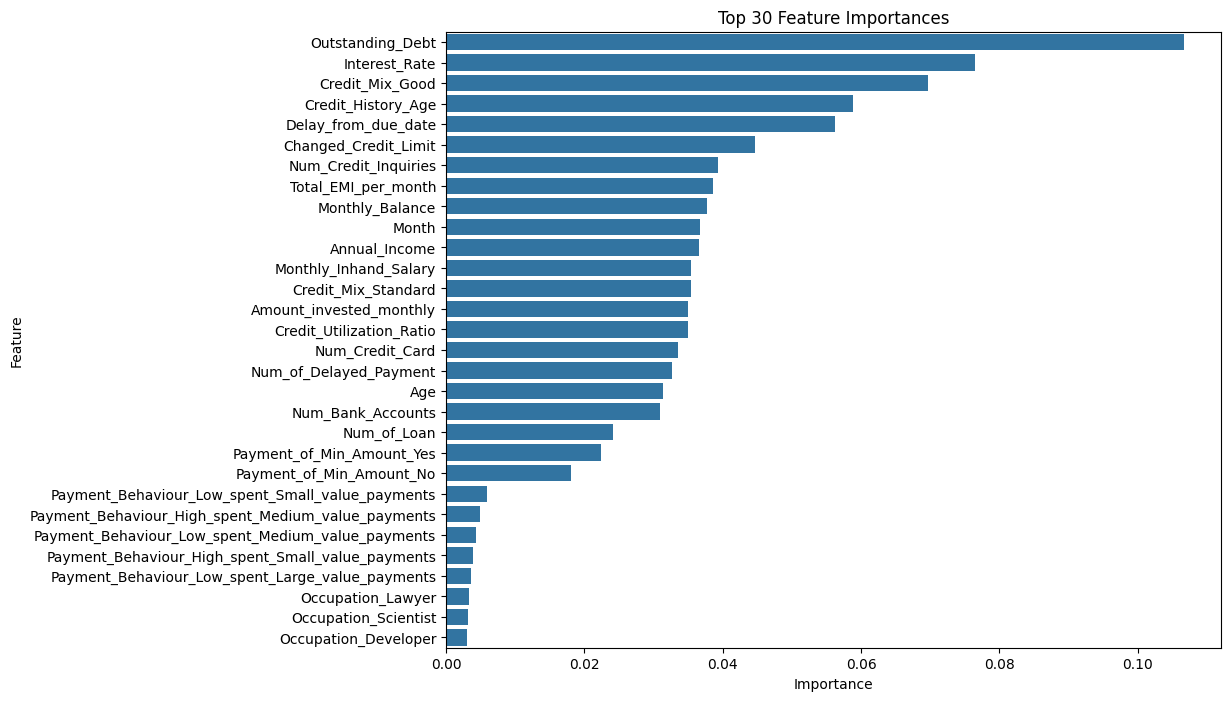

In [192]:
# 상위 30개 변수 중요도 시각화
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance_df.head(30),
    x='importance',
    y='feature'
)

plt.title('Top 30 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [193]:
# 선택할 feature 개수 지정
top_n = 50
# 사실 이 부분에서는 애초에 feature 개수가 50개이므로, 당연히 변수 선택 효과는 없을 것이다. 그러나, 어떤 변수가 중요한지를 파악하는 것이 우선이며
# 이후에 모델 성능이 안나올시, 이 feature 개수를 줄이는 방법을 고려해 볼 수 있을 것이다.

# 전체 feature 수보다 top_n이 크면 전체 feature 수로 조정
top_n = min(top_n, X_train_scaled.shape[1])

# 상위 N개 feature 선택
selected_features = feature_importance_df.head(top_n)['feature'].tolist()

print("선택된 Feature 개수:", len(selected_features))
print(selected_features)

선택된 Feature 개수: 50
['Outstanding_Debt', 'Interest_Rate', 'Credit_Mix_Good', 'Credit_History_Age', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Total_EMI_per_month', 'Monthly_Balance', 'Month', 'Annual_Income', 'Monthly_Inhand_Salary', 'Credit_Mix_Standard', 'Amount_invested_monthly', 'Credit_Utilization_Ratio', 'Num_Credit_Card', 'Num_of_Delayed_Payment', 'Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Payment_of_Min_Amount_Yes', 'Payment_of_Min_Amount_No', 'Payment_Behaviour_Low_spent_Small_value_payments', 'Payment_Behaviour_High_spent_Medium_value_payments', 'Payment_Behaviour_Low_spent_Medium_value_payments', 'Payment_Behaviour_High_spent_Small_value_payments', 'Payment_Behaviour_Low_spent_Large_value_payments', 'Occupation_Lawyer', 'Occupation_Scientist', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Mechanic', 'Occupation_Entrepreneur', 'Occupation_Engineer', 'Occupation_Architect', 'Occupation_Manager', 'Occupation_Teacher', 'Occupation_Media_Ma

In [194]:
# 선택된 변수만 추출
X_train_selected = X_train_scaled[selected_features]
X_val_selected = X_val_scaled[selected_features]

print("Feature Selection 전 X_train 크기:", X_train_scaled.shape)
print("Feature Selection 후 X_train 크기:", X_train_selected.shape)

print("Feature Selection 전 X_val 크기:", X_val_scaled.shape)
print("Feature Selection 후 X_val 크기:", X_val_selected.shape)

Feature Selection 전 X_train 크기: (80000, 50)
Feature Selection 후 X_train 크기: (80000, 50)
Feature Selection 전 X_val 크기: (20000, 50)
Feature Selection 후 X_val 크기: (20000, 50)


In [195]:
# 딥러닝 모델 입력을 위해 float32로 변환
X_train_selected = X_train_selected.astype('float32')
X_val_selected = X_val_selected.astype('float32')

print("X_train_selected 타입:", X_train_selected.dtypes.unique())
print("X_val_selected 타입:", X_val_selected.dtypes.unique())

X_train_selected 타입: [dtype('float32')]
X_val_selected 타입: [dtype('float32')]


In [196]:
# 선택된 변수의 중요도 확인
selected_importance_df = feature_importance_df[
    feature_importance_df['feature'].isin(selected_features)
]

selected_importance_df

,feature,importance,cumulative_importance
12,Outstanding_Debt,0.106709,0.106709
6,Interest_Rate,0.076534,0.183243
41,Credit_Mix_Good,0.069722,0.252966
14,Credit_History_Age,0.058791,0.311756
8,Delay_from_due_date,0.056269,0.368025
10,Changed_Credit_Limit,0.044607,0.412632
11,Num_Credit_Inquiries,0.039298,0.451930
15,Total_EMI_per_month,0.038533,0.490463
17,Monthly_Balance,0.037780,0.528243
0,Month,0.036702,0.564944


month 변수도 상위 중요도에 포함되었으나, 이는 신용 행동 자체라기보다 관측 시점에 따른 신용정보 변화가 반영된 결과일 수 있다.
따라서 핵심 신용 요인으로 단정하기보다는 보조적인 시간 정보로 해석하였다.

# 9. MLP 딥러닝 모델 구축
정형 데이터를 다루고 있으므로, 이미지 처리에 적합한 CNN이나 순차 데이터에 적합한 RNN보다, 여러 feature 간의 비선형 관계를 학습할 수 있는 MLP 모델을 사용한다.

In [197]:
# 추가 개선 사항1. Bigger MLP + Lower Learning Rate + Lower Dropout

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_dim = X_train_selected.shape[1]
num_classes = len(np.unique(y_train))

model_exp5 = Sequential()

model_exp5.add(Dense(256, activation='relu', input_shape=(input_dim,)))
model_exp5.add(BatchNormalization())
model_exp5.add(Dropout(0.2))

model_exp5.add(Dense(128, activation='relu'))
model_exp5.add(BatchNormalization())
model_exp5.add(Dropout(0.15))

model_exp5.add(Dense(64, activation='relu'))
model_exp5.add(BatchNormalization())
model_exp5.add(Dropout(0.1))

model_exp5.add(Dense(32, activation='relu'))
model_exp5.add(Dropout(0.05))

model_exp5.add(Dense(num_classes, activation='softmax'))

model_exp5.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_exp5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,179 (227.26 KB)

 Trainable params: 57,283 (223.76 KB)

 Non-trainable params: 896 (3.50 KB)

In [115]:
# 개선 실험 1. 모델 구조 확장 MLP

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# 입력 feature 개수
input_dim = X_train_selected.shape[1]

# 타겟 클래스 개수
num_classes = len(np.unique(y_train))

print("입력 feature 개수:", input_dim)
print("타겟 클래스 개수:", num_classes)

# 기존 model과 구분하기 위해 새로운 모델명 사용
model_exp1 = Sequential()

# 입력층 + 첫 번째 은닉층
model_exp1.add(Dense(256, activation='relu', input_shape=(input_dim,)))
model_exp1.add(BatchNormalization())
model_exp1.add(Dropout(0.3))

# 두 번째 은닉층
model_exp1.add(Dense(128, activation='relu'))
model_exp1.add(BatchNormalization())
model_exp1.add(Dropout(0.25))

# 세 번째 은닉층
model_exp1.add(Dense(64, activation='relu'))
model_exp1.add(BatchNormalization())
model_exp1.add(Dropout(0.2))

# 네 번째 은닉층
model_exp1.add(Dense(32, activation='relu'))
model_exp1.add(Dropout(0.1))

# 출력층
model_exp1.add(Dense(num_classes, activation='softmax'))

# 모델 컴파일
model_exp1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model_exp1.summary()

입력 feature 개수: 50
타겟 클래스 개수: 3


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,179 (227.26 KB)

 Trainable params: 57,283 (223.76 KB)

 Non-trainable params: 896 (3.50 KB)

In [74]:
# 베이스라인 모델

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# 입력 feature 개수
input_dim = X_train_selected.shape[1]

# 타겟 클래스 개수
num_classes = len(np.unique(y_train))

print("입력 feature 개수:", input_dim)
print("타겟 클래스 개수:", num_classes)

# MLP 모델 생성
model = Sequential()

# 은닉층은 128-64-32 구조로 구성하여 초기 층에서는 다양한 변수 조합을 학습하고, 이후 층에서는 핵심 패턴을 점진적으로 압축하도록 설계하였다.
# 입력층 + 첫 번째 은닉층
model.add(Dense(128, activation='relu', input_shape=(input_dim,)))  # 활성화 함수 종류는 은닉층에서 기본 선택지로 많이 쓰이는 ReLU로 설정한다.
model.add(BatchNormalization()) # 각 미니배치 안에서 값의 분포를 정규화하여 기울기 문제를 완화하여 오버피팅을 해결하는 방법인 BatchNormalization을 사용한다.
model.add(Dropout(0.3)) # 신경망이 특정 뉴런에 과도하게 의존하는 것을 막기 위해 드롭아웃을 사용한다.(과대적합 감소, 일반화 성능을 높임)

# 두 번째 은닉층
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# 세 번째 은닉층
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

# 출력층
model.add(Dense(num_classes, activation='softmax')) # 출력층에서는 다중분류 문제에 적합한 활성화함수인 softmax를 사용한다.

# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

입력 feature 개수: 50
타겟 클래스 개수: 3


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,731 (69.26 KB)

 Trainable params: 17,347 (67.76 KB)

 Non-trainable params: 384 (1.50 KB)

# 10. 모델 학습

In [198]:
# 추가 개선 사항1
early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_exp5 = model_exp5.fit(
    X_train_selected,
    y_train,
    validation_data=(X_val_selected, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6589 - loss: 0.7395 - val_accuracy: 0.6982 - val_loss: 0.6598 - learning_rate: 5.0000e-04
Epoch 2/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6890 - loss: 0.6748 - val_accuracy: 0.7052 - val_loss: 0.6464 - learning_rate: 5.0000e-04
Epoch 3/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6980 - loss: 0.6603 - val_accuracy: 0.7070 - val_loss: 0.6406 - learning_rate: 5.0000e-04
Epoch 4/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7007 - loss: 0.6531 - val_accuracy: 0.7095 - val_loss: 0.6388 - learning_rate: 5.0000e-04
Epoch 5/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7045 - loss: 0.6468 - val_accuracy: 0.7106 - val_loss: 0.6363 - learning_rate: 5.0000e-04
Epoch 6/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7065 - loss: 0.6402 - val_accuracy: 0.7113 - val_loss: 0.6330 - learning_rate: 5.0000e-04
Epoch 7/80
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/st

In [116]:
# 개선 실험 1. 모델 학습

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_exp1 = model_exp1.fit(
    X_train_selected,
    y_train,
    validation_data=(X_val_selected, y_val),
    epochs=50,
    batch_size=64,        # 기존과 동일하게 유지
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6517 - loss: 0.7514 - val_accuracy: 0.6959 - val_loss: 0.6622 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6870 - loss: 0.6805 - val_accuracy: 0.7020 - val_loss: 0.6506 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6945 - loss: 0.6659 - val_accuracy: 0.7034 - val_loss: 0.6462 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7015 - loss: 0.6577 - val_accuracy: 0.7041 - val_loss: 0.6430 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7012 - loss: 0.6525 - val_accuracy: 0.7068 - val_loss: 0.6385 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7049 - loss: 0.6472 - val_accuracy: 0.7071 - val_loss: 0.6362 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7054 - loss: 0.6444 -

In [ ]:
# 베이스라인
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# validation loss가 더 이상 개선되지 않으면 학습을 조기 종료하기 위해 EarlyStopping을 사용한다.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# validation loss 개선이 정체되면 learning rate를 감소하기 위해 ReduceLROnPlateau을 사용한다.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 모델 학습
history = model.fit(
    X_train_selected,
    y_train,
    validation_data=(X_val_selected, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Loss 그래프
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Accuracy 그래프
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# 모델 학습에서는 train 데이터로 MLP 모델을 학습하고 validation 데이터로 일반화 성능을 확인하였다.
# epochs는 최대 50으로 설정하였지만, validation loss가 일정 기간 개선되지 않으면 EarlyStopping을 통해 학습을 조기 종료하도록 하였다.
# 이는 학습 데이터에만 과도하게 적합되는 과적합을 방지하기 위한 목적이다.
# 또한 ReduceLROnPlateau를 사용하여 validation loss 개선이 정체될 경우 learning rate를 절반으로 줄이도록 설정하였다.
# 이를 통해 학습 후반부에 더 작은 보폭으로 최적점을 탐색할 수 있도록 하였다.
# 학습 이후 train loss와 validation loss, train accuracy와 validation accuracy를 시각화하여 과적합 여부를 확인하였다.

# 11.  Validation score 출력

In [199]:
# 추가 개선 사항1

from sklearn.metrics import accuracy_score, f1_score, classification_report

y_val_pred_prob_exp5 = model_exp5.predict(X_val_selected)
y_val_pred_exp5 = np.argmax(y_val_pred_prob_exp5, axis=1)

val_loss_exp5, val_acc_exp5 = model_exp5.evaluate(X_val_selected, y_val, verbose=0)

val_accuracy_exp5 = accuracy_score(y_val, y_val_pred_exp5)
val_macro_f1_exp5 = f1_score(y_val, y_val_pred_exp5, average='macro')
val_weighted_f1_exp5 = f1_score(y_val, y_val_pred_exp5, average='weighted')

print("========== Exp5 Evaluation ==========")
print("Validation Loss:", round(val_loss_exp5, 4))
print("Validation Accuracy:", round(val_accuracy_exp5, 4))
print("Validation Macro F1-score:", round(val_macro_f1_exp5, 4))
print("Validation Weighted F1-score:", round(val_weighted_f1_exp5, 4))

print("\n========== Classification Report ==========")
print(classification_report(
    y_val,
    y_val_pred_exp5,
    target_names=le.classes_
))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== Exp5 Evaluation ==========
Validation Loss: 0.5517
Validation Accuracy: 0.7664
Validation Macro F1-score: 0.7565
Validation Weighted F1-score: 0.7672

========== Classification Report ==========
              precision    recall  f1-score   support

        Good       0.68      0.77      0.72      3566
        Poor       0.75      0.78      0.77      5799
    Standard       0.81      0.76      0.78     10635

    accuracy                           0.77     20000
   macro avg       0.75      0.77      0.76     20000
weighted avg       0.77      0.77      0.77     20000



In [118]:
# 개선 실험 1. Validation score 출력

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# validation 데이터 예측
y_val_pred_prob_exp1 = model_exp1.predict(X_val_selected)
y_val_pred_exp1 = np.argmax(y_val_pred_prob_exp1, axis=1)

# Keras 평가
val_loss_exp1, val_acc_exp1 = model_exp1.evaluate(X_val_selected, y_val, verbose=0)

# sklearn 평가
val_accuracy_exp1 = accuracy_score(y_val, y_val_pred_exp1)
val_macro_f1_exp1 = f1_score(y_val, y_val_pred_exp1, average='macro')
val_weighted_f1_exp1 = f1_score(y_val, y_val_pred_exp1, average='weighted')

print("========== Exp1: Bigger MLP Evaluation ==========")
print("Validation Loss:", round(val_loss_exp1, 4))
print("Validation Accuracy:", round(val_accuracy_exp1, 4))
print("Validation Macro F1-score:", round(val_macro_f1_exp1, 4))
print("Validation Weighted F1-score:", round(val_weighted_f1_exp1, 4))

print("\n========== Classification Report ==========")
print(classification_report(
    y_val,
    y_val_pred_exp1,
    target_names=le.classes_
))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== Exp3: Bigger MLP Evaluation+ batch size change ==========
Validation Loss: 0.5852
Validation Accuracy: 0.7357
Validation Macro F1-score: 0.7219
Validation Weighted F1-score: 0.7368

========== Classification Report ==========
              precision    recall  f1-score   support

        Good       0.62      0.74      0.68      3566
        Poor       0.74      0.71      0.72      5799
    Standard       0.78      0.75      0.76     10635

    accuracy                           0.74     20000
   macro avg       0.72      0.73      0.72     20000
weighted avg       0.74      0.74      0.74     20000



625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== Keras Evaluation ==========
Validation Loss: 0.5999
Validation Accuracy: 0.726

========== Sklearn Evaluation ==========
Validation Accuracy: 0.726
Validation Macro F1-score: 0.7083
Validation Weighted F1-score: 0.7265

========== Classification Report ==========
              precision    recall  f1-score   support

        Good       0.62      0.71      0.66      3566
        Poor       0.74      0.67      0.70      5799
    Standard       0.76      0.76      0.76     10635

    accuracy                           0.73     20000
   macro avg       0.71      0.71      0.71     20000
weighted avg       0.73      0.73      0.73     20000


========== Confusion Matrix ==========


,Good,Poor,Standard
Good,2526,95,945
Poor,295,3879,1625
Standard,1267,1253,8115


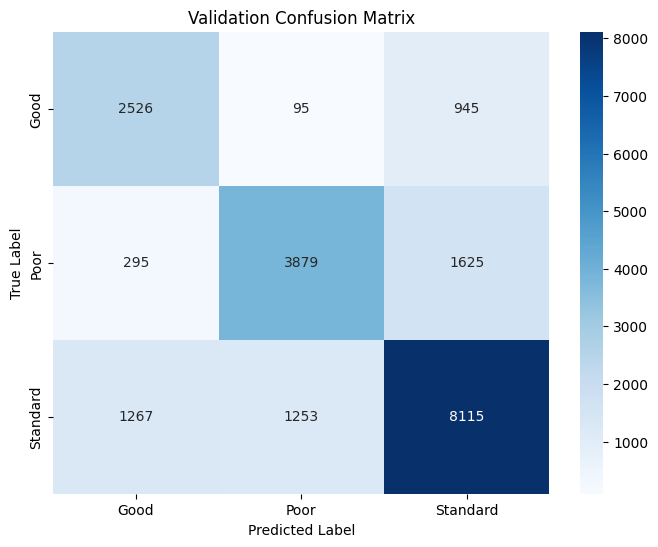

In [77]:
# 베이스라인
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# validation 데이터 예측 확률
y_val_pred_prob = model.predict(X_val_selected)

# 가장 확률이 높은 클래스를 최종 예측값으로 변환
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

# Keras evaluate를 통한 validation loss, accuracy 확인
val_loss, val_acc = model.evaluate(X_val_selected, y_val, verbose=0)

print("========== Keras Evaluation ==========")
print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_acc, 4))

# sklearn 기반 평가 지표 계산
val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
val_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("\n========== Sklearn Evaluation ==========")
print("Validation Accuracy:", round(val_accuracy, 4))
print("Validation Macro F1-score:", round(val_macro_f1, 4))
print("Validation Weighted F1-score:", round(val_weighted_f1, 4))

# 클래스별 평가 지표 출력
print("\n========== Classification Report ==========")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=le.classes_
))

# Confusion Matrix 생성
cm = confusion_matrix(y_val, y_val_pred)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

print("\n========== Confusion Matrix ==========")
display(cm_df)

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 1. **Baseline 모델 성능 기록(계속해서 수정할 것이기 때문)**

Validation Accuracy: 0.7244  
Validation Macro F1-score: 0.7074  
Validation Weighted F1-score: 0.7253   

========== Classification Report ==========   
              precision    recall  f1-score   support

        Good       0.60      0.73      0.66      3566
        Poor       0.75      0.67      0.70      5799
    Standard       0.76      0.76      0.76     10635

    accuracy                           0.72     20000
   macro avg       0.70      0.72      0.71     20000
weighted avg       0.73      0.72      0.73     20000

Validation Accuracy가 0.7244 로 목표치인 75보다 낮게 나왔다. 이를 개선하기 위해 다음과 같은 방법을 생각해 볼 수 있다.

1. 모델 구조를 조금 키우기
- 단순히 feature 개수를 줄이는 것 보다, layer를 더 추가해서 더 깊은 MLP 모델을 만들어 본다.

2. batch size를 64에서 128로 바꿔본다.
- 배치 사이즈를 조금 더 키워본다.

3. class_weight 적용해보기
-현재 클래스 분포가 완전히 균등하지 않아서 class_weight를 적용하면 Good의 클래스 성능이 개선될 수 있다.

1번부터 차례대로 적용해본다.

# 2. **개선 사항 1번 모델 결과**  
Validation Loss: 0.5843   
Validation Accuracy: 0.7366    
Validation Macro F1-score: 0.7223    
Validation Weighted F1-score: 0.7375    

# 3. **개선 사항 2번 모델 결과**  
Validation Accuracy: 0.726   
Validation Macro F1-score: 0.7083   
Validation Weighted F1-score: 0.7265   

# 4. **개선 사항 3번 모델 결과**
Validation Loss: 0.6693   
Validation Accuracy: 0.6884   
Validation Macro F1-score: 0.6848   
Validation Weighted F1-score: 0.6899   



class_weight를 적용한 결과 validation accuracy가 0.6884로 baseline보다 낮아졌다.
이는 클래스 불균형 보정이 이번 데이터에서는 모델의 일반화 성능 개선으로 이어지지 않았음을 의미한다.

# **정리**  
batch size를 조절하는 것 보다, 모델 구조를 조금 키우기만 하는 것이 가장 높은 성능을 보였다. 개선사항 1+2번 결과도 단순 1번보다 성능이 낮았기 때문에, 1차적으로 최종모델은 개선 사항 1번 모델로 선정한다.

# 추가 개선사항1: Exp1 구조 유지 + learning_rate 낮추기 + Dropout 조금 줄이기
방법을 적용해본다.

# 추가 개선사항2: 파생변수를 생성해본다.

# **추가 개선사항1 모델 결과**  
Validation Loss: 0.5517  
Validation Accuracy: 0.7664  
Validation Macro F1-score: 0.7565  
Validation Weighted F1-score: 0.7672  

-> 최종 모델로 선정

 Exp5 모델은 256-128-64-32 구조의 Bigger MLP를 사용하고,
learning rate를 0.0005로 낮추며 Dropout 비율을 조정한 모델이다.
검증 결과 Validation Accuracy는 0.7664, Macro F1-score는 0.7565로 나타나 목표 기준인 0.75를 달성하였다.